In [7]:

import random
import numpy as np
import torch
import monai

def set_seed(seed=42):
    """Locks all random number generators for exact reproducibility."""
    # 1. Set Python and Numpy seeds
    random.seed(seed)
    np.random.seed(seed)
    
    # 2. Set PyTorch seeds
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
        # Force cuDNN to behave deterministically (might slightly slow down training)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # 3. Set MONAI's internal seed for its randomized transforms
    monai.utils.set_determinism(seed=seed)

# Call the function immediately to lock everything in
set_seed(42)

In [ ]:
import torch
from monai.data import ImageDataset, DataLoader
from monai.transforms import EnsureChannelFirst, Compose, Rand3DElastic, Resize, ScaleIntensity, RandShiftIntensity
import monai
from torch.utils.tensorboard import SummaryWriter
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms from the MONAI tutorial
train_transforms = Compose([ScaleIntensity(), 
                            EnsureChannelFirst(), 
                            Resize((96, 96, 96)),
                            Rand3DElastic(prob=0.5, sigma_range=(5, 7), magnitude_range=(50, 150),spatial_size=(96, 96, 96), padding_mode="border"),
                            RandShiftIntensity(prob=0.5, offsets=0.10)
])

val_transforms = Compose([ScaleIntensity(), EnsureChannelFirst(), Resize((96, 96, 96))])

## 1. Load the locked-in splits
load_path = os.path.expanduser('~/Desktop/brain-math/deeplearn/GLM/GLM_kfold_splits.json')
with open(load_path, 'r') as f:
    saved_splits = json.load(f)

# 2. Select which fold you want to train right now
current_fold = "fold_1"  # Change this to "fold_2", "fold_3", etc., when ready
print(f"Loading data for {current_fold}...")

fold_data = saved_splits[current_fold]
train_images = fold_data["train_images"]
val_images = fold_data["val_images"]

# 3. Convert the saved integer labels (0 or 1) back into one-hot tensors for MONAI
train_labels = torch.nn.functional.one_hot(torch.as_tensor(fold_data["train_labels"])).float()
val_labels = torch.nn.functional.one_hot(torch.as_tensor(fold_data["val_labels"])).float()

# 4. Create your MONAI Datasets
train_ds = ImageDataset(image_files=train_images, labels=train_labels, transform=train_transforms)
val_ds = ImageDataset(image_files=val_images, labels=val_labels, transform=val_transforms)

# 5. Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=2, num_workers=2, pin_memory=torch.cuda.is_available())

# Create DenseNet121, CrossEntropyLoss and Adam optimizer
model = monai.networks.nets.DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(device)

loss_function = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), 1e-4)

# start a typical PyTorch training
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
writer = SummaryWriter()
max_epochs = 150

patience = 10            # Stop after 10 validation checks without improvement
patience_counter = 0     # Tracks how long we've gone without a new best score

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_len = len(train_ds) // train_loader.batch_size
        print(f"{step}/{epoch_len}, train_loss: {loss.item():.4f}")
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")


    model.eval()

    num_correct = 0.0
    metric_count = 0
    for val_data in val_loader:
        val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
        with torch.no_grad():
            val_outputs = model(val_images)
            value = torch.eq(val_outputs.argmax(dim=1), val_labels.argmax(dim=1))
            metric_count += len(value)
            num_correct += value.sum().item()

    metric = num_correct / metric_count
    metric_values.append(metric)

    if metric > best_metric:
        best_metric = metric
        best_metric_epoch = epoch + 1
        patience_counter = 0  # reset patience if it improves
        torch.save(model.state_dict(), "best_densenet121_classification3d_array.pth")
        print("saved new best metric model")
    else:
        patience_counter += 1 # increment patience if it failed to improve
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    print(f"Current epoch: {epoch+1} current accuracy: {metric:.4f} ")
    print(f"Best accuracy: {best_metric:.4f} at epoch {best_metric_epoch}")
    writer.add_scalar("val_accuracy", metric, epoch + 1)

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}!")
        print(f"Validation accuracy hasn't improved in {patience} epochs.")
        break

print(f"Training completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
writer.close()

Loading data for fold_1...
----------
epoch 1/150
1/96, train_loss: 0.6913
2/96, train_loss: 0.7487
3/96, train_loss: 0.7428
4/96, train_loss: 0.6754
5/96, train_loss: 0.7345
6/96, train_loss: 0.8287
7/96, train_loss: 0.7102
8/96, train_loss: 0.6023
9/96, train_loss: 0.6833
10/96, train_loss: 0.7471
11/96, train_loss: 0.6088
12/96, train_loss: 0.5432
13/96, train_loss: 0.6336
14/96, train_loss: 0.6266
15/96, train_loss: 0.3391
16/96, train_loss: 0.8624
17/96, train_loss: 1.4044
18/96, train_loss: 0.7943
19/96, train_loss: 0.8712
20/96, train_loss: 0.5629
21/96, train_loss: 0.6385
22/96, train_loss: 0.5780
23/96, train_loss: 0.9259
24/96, train_loss: 0.5150
25/96, train_loss: 0.4671
26/96, train_loss: 0.5728
27/96, train_loss: 0.8857
28/96, train_loss: 0.5040
29/96, train_loss: 1.1322
30/96, train_loss: 1.0873
31/96, train_loss: 0.5520
32/96, train_loss: 1.0376
33/96, train_loss: 0.4956
34/96, train_loss: 0.5768
35/96, train_loss: 0.6660
36/96, train_loss: 0.9223
37/96, train_loss: 0.33

In [8]:
import torch
from monai.data import ImageDataset, DataLoader
from monai.transforms import EnsureChannelFirst, Compose, Rand3DElastic, Resize, ScaleIntensity, RandShiftIntensity
import monai
from torch.utils.tensorboard import SummaryWriter
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms from the MONAI tutorial
train_transforms = Compose([ScaleIntensity(), 
                            EnsureChannelFirst(), 
                            Resize((96, 96, 96)),
                            Rand3DElastic(prob=0.5, sigma_range=(5, 7), magnitude_range=(50, 150),spatial_size=(96, 96, 96), padding_mode="border"),
                            RandShiftIntensity(prob=0.5, offsets=0.10)
])

val_transforms = Compose([ScaleIntensity(), EnsureChannelFirst(), Resize((96, 96, 96))])

## 1. Load the locked-in splits
load_path = os.path.expanduser('~/Desktop/brain-math/deeplearn/GLM/GLM_kfold_splits.json')
with open(load_path, 'r') as f:
    saved_splits = json.load(f)

# 2. Select which fold you want to train right now
current_fold = "fold_2"  # Change this to "fold_2", "fold_3", etc., when ready
print(f"Loading data for {current_fold}...")

fold_data = saved_splits[current_fold]
train_images = fold_data["train_images"]
val_images = fold_data["val_images"]

# 3. Convert the saved integer labels (0 or 1) back into one-hot tensors for MONAI
train_labels = torch.nn.functional.one_hot(torch.as_tensor(fold_data["train_labels"])).float()
val_labels = torch.nn.functional.one_hot(torch.as_tensor(fold_data["val_labels"])).float()

# 4. Create your MONAI Datasets
train_ds = ImageDataset(image_files=train_images, labels=train_labels, transform=train_transforms)
val_ds = ImageDataset(image_files=val_images, labels=val_labels, transform=val_transforms)

# 5. Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=2, num_workers=2, pin_memory=torch.cuda.is_available())

# Create DenseNet121, CrossEntropyLoss and Adam optimizer
model = monai.networks.nets.DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(device)

loss_function = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-5)

# start a typical PyTorch training
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
writer = SummaryWriter()
max_epochs = 150

patience = 10            # Stop after 10 validation checks without improvement
patience_counter = 0     # Tracks how long we've gone without a new best score

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_len = len(train_ds) // train_loader.batch_size
        print(f"{step}/{epoch_len}, train_loss: {loss.item():.4f}")
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")


    model.eval()

    num_correct = 0.0
    metric_count = 0
    for val_data in val_loader:
        val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
        with torch.no_grad():
            val_outputs = model(val_images)
            value = torch.eq(val_outputs.argmax(dim=1), val_labels.argmax(dim=1))
            metric_count += len(value)
            num_correct += value.sum().item()

    metric = num_correct / metric_count
    metric_values.append(metric)

    if metric > best_metric:
        best_metric = metric
        best_metric_epoch = epoch + 1
        patience_counter = 0  # reset patience if it improves
        torch.save(model.state_dict(), "best_densenet121_classification3d_array.pth")
        print("saved new best metric model")
    else:
        patience_counter += 1 # increment patience if it failed to improve
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    print(f"Current epoch: {epoch+1} current accuracy: {metric:.4f} ")
    print(f"Best accuracy: {best_metric:.4f} at epoch {best_metric_epoch}")
    writer.add_scalar("val_accuracy", metric, epoch + 1)

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}!")
        print(f"Validation accuracy hasn't improved in {patience} epochs.")
        break

print(f"Training completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
writer.close()

Loading data for fold_2...
----------
epoch 1/150
1/95, train_loss: 0.7943
2/95, train_loss: 0.6373
3/95, train_loss: 0.6363
4/95, train_loss: 0.6700
5/95, train_loss: 0.7717
6/95, train_loss: 0.7884
7/95, train_loss: 0.6181
8/95, train_loss: 0.5797
9/95, train_loss: 0.8298
10/95, train_loss: 0.6084
11/95, train_loss: 0.7644
12/95, train_loss: 0.6196
13/95, train_loss: 0.7720
14/95, train_loss: 0.7136
15/95, train_loss: 0.7470
16/95, train_loss: 0.7514
17/95, train_loss: 0.7610
18/95, train_loss: 0.6778
19/95, train_loss: 0.6956
20/95, train_loss: 0.8555
21/95, train_loss: 0.8229
22/95, train_loss: 0.7248
23/95, train_loss: 0.7009
24/95, train_loss: 0.6706
25/95, train_loss: 0.7157
26/95, train_loss: 0.6843
27/95, train_loss: 0.9230
28/95, train_loss: 0.7249
29/95, train_loss: 0.7336
30/95, train_loss: 0.7625
31/95, train_loss: 0.9879
32/95, train_loss: 0.7169
33/95, train_loss: 0.7347
34/95, train_loss: 0.7155
35/95, train_loss: 0.7029
36/95, train_loss: 0.7242
37/95, train_loss: 0.67

## Learning Rate Finder

Loading data for fold_2...
Running Learning Rate Finder...


Computing optimal learning rate: 100%|██████████| 200/200 [18:35<00:00,  5.58s/it]


Resetting model and optimizer
Suggested Learning Rate: 8.172134968782195e-05


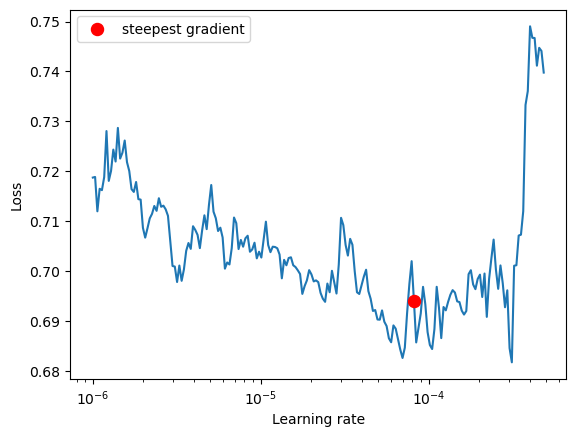

In [4]:
import torch
from monai.data import ImageDataset, DataLoader
import json
import os

load_path = os.path.expanduser('~/Desktop/brain-math/deeplearn/GLM/GLM_kfold_splits.json')
with open(load_path, 'r') as f:
    saved_splits = json.load(f)

# 2. Select which fold you want to train right now
current_fold = "fold_2"  # Change this to "fold_2", "fold_3", etc., when ready
print(f"Loading data for {current_fold}...")

fold_data = saved_splits[current_fold]
train_images = fold_data["train_images"]

# 3. Convert the saved integer labels (0 or 1) back into one-hot tensors for MONAI
train_labels = torch.nn.functional.one_hot(torch.as_tensor(fold_data["train_labels"])).float()

# 4. Create your MONAI Datasets
train_ds = ImageDataset(image_files=train_images, labels=train_labels, transform=train_transforms)

# 5. Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())

# Create DenseNet121, CrossEntropyLoss and Adam optimizer
model = monai.networks.nets.DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(device)

loss_function = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), 1e-4)

# 2. Initialize the Learning Rate Finder
lr_finder = monai.optimizers.LearningRateFinder(
    model=model, 
    optimizer=optimizer, 
    criterion=loss_function, 
    device=device
)

# 3. Run the Range Test
# This runs the model for 'num_iter' batches, increasing the LR up to 'end_lr'
print("Running Learning Rate Finder...")
lr_finder.range_test(
    train_loader, 
    start_lr=1e-6, 
    end_lr=5e-4, 
    num_iter=200 # Adjust based on your dataset size
)

# 4. Get the Suggested Learning Rate
# MONAI automatically calculates the point of steepest descent
steepest_lr, steepest_loss = lr_finder.get_steepest_gradient()
print(f"Suggested Learning Rate: {steepest_lr}")

# 5. Plot the Results (Crucial for visual confirmation)
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
lr_finder.plot(ax=ax)
plt.show()

# 6. RESET THE MODEL (Extremely Important!)
# The range_test messes up your model weights by pushing them to divergence.
# You MUST reset it back to its initial state before starting actual training.
lr_finder.reset()

## Reduce LROnPlateau

In [9]:
import torch
from monai.data import ImageDataset, DataLoader
from monai.transforms import EnsureChannelFirst, Compose, Rand3DElastic, Resize, ScaleIntensity, RandShiftIntensity
import monai
from torch.utils.tensorboard import SummaryWriter
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms from the MONAI tutorial
train_transforms = Compose([ScaleIntensity(), 
                            EnsureChannelFirst(), 
                            Resize((96, 96, 96)),
                            Rand3DElastic(prob=0.5, sigma_range=(5, 7), magnitude_range=(50, 150),spatial_size=(96, 96, 96), padding_mode="border"),
                            RandShiftIntensity(prob=0.5, offsets=0.10)
])

val_transforms = Compose([ScaleIntensity(), EnsureChannelFirst(), Resize((96, 96, 96))])

## 1. Load the locked-in splits
load_path = os.path.expanduser('~/Desktop/brain-math/deeplearn/GLM/GLM_kfold_splits.json')
with open(load_path, 'r') as f:
    saved_splits = json.load(f)

# 2. Select which fold you want to train right now
current_fold = "fold_2"  # Change this to "fold_2", "fold_3", etc., when ready
print(f"Loading data for {current_fold}...")

fold_data = saved_splits[current_fold]
train_images = fold_data["train_images"]
val_images = fold_data["val_images"]

# 3. Convert the saved integer labels (0 or 1) back into one-hot tensors for MONAI
train_labels = torch.nn.functional.one_hot(torch.as_tensor(fold_data["train_labels"])).float()
val_labels = torch.nn.functional.one_hot(torch.as_tensor(fold_data["val_labels"])).float()

# 4. Create your MONAI Datasets
train_ds = ImageDataset(image_files=train_images, labels=train_labels, transform=train_transforms)
val_ds = ImageDataset(image_files=val_images, labels=val_labels, transform=val_transforms)

# 5. Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=2, num_workers=2, pin_memory=torch.cuda.is_available())

# Create DenseNet121, CrossEntropyLoss and Adam optimizer
model = monai.networks.nets.DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(device)

loss_function = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # We want the validation loss to go DOWN
    factor=0.5,        # Multiply LR by 0.5 when plateauing
    patience=5,        # Wait 5 epochs before dropping LR
    min_lr=1e-7        # Absolute minimum LR
)

# start a typical PyTorch training
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
writer = SummaryWriter()
max_epochs = 150

patience = 10            # Stop after 10 validation checks without improvement
patience_counter = 0     # Tracks how long we've gone without a new best score

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_len = len(train_ds) // train_loader.batch_size
        print(f"{step}/{epoch_len}, train_loss: {loss.item():.4f}")
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")


    model.eval()

    num_correct = 0.0
    metric_count = 0
    val_loss_sum = 0.0
    for val_data in val_loader:
        val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
        with torch.no_grad():
            val_outputs = model(val_images)
            val_loss = loss_function(val_outputs, val_labels)
            val_loss_sum += val_loss.item()
            value = torch.eq(val_outputs.argmax(dim=1), val_labels.argmax(dim=1))
            metric_count += len(value)
            num_correct += value.sum().item()

    metric = num_correct / metric_count
    metric_values.append(metric)

    avg_val_loss = val_loss_sum / len(val_loader)

    if metric > best_metric:
        best_metric = metric
        best_metric_epoch = epoch + 1
        patience_counter = 0  # reset patience if it improves
        torch.save(model.state_dict(), "best_densenet121_classification3d_array.pth")
        print("saved new best metric model")
    else:
        patience_counter += 1 # increment patience if it failed to improve
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    print(f"Current epoch: {epoch+1} current accuracy: {metric:.4f} ")
    print(f"Best accuracy: {best_metric:.4f} at epoch {best_metric_epoch}")
    writer.add_scalar("val_accuracy", metric, epoch + 1)

    scheduler.step(avg_val_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr}")

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}!")
        print(f"Validation accuracy hasn't improved in {patience} epochs.")
        break

print(f"Training completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
writer.close()

Loading data for fold_2...
----------
epoch 1/150
1/96, train_loss: 0.4932
2/96, train_loss: 0.8140
3/96, train_loss: 0.6940
4/96, train_loss: 1.0200
5/96, train_loss: 0.5550
6/96, train_loss: 0.8070
7/96, train_loss: 0.9613
8/96, train_loss: 0.7077
9/96, train_loss: 0.5032
10/96, train_loss: 0.6075
11/96, train_loss: 1.3529
12/96, train_loss: 0.5380
13/96, train_loss: 1.1817
14/96, train_loss: 0.5232
15/96, train_loss: 0.8582
16/96, train_loss: 0.5327
17/96, train_loss: 0.5229
18/96, train_loss: 0.9119
19/96, train_loss: 0.9246
20/96, train_loss: 0.9319
21/96, train_loss: 0.5426
22/96, train_loss: 0.5856
23/96, train_loss: 0.6737
24/96, train_loss: 0.8866
25/96, train_loss: 0.5453
26/96, train_loss: 1.0383
27/96, train_loss: 0.8816
28/96, train_loss: 0.9150
29/96, train_loss: 1.1054
30/96, train_loss: 1.0656
31/96, train_loss: 1.0426
32/96, train_loss: 0.8076
33/96, train_loss: 0.8039
34/96, train_loss: 0.6881
35/96, train_loss: 0.6775
36/96, train_loss: 0.6337
37/96, train_loss: 0.80

## Experiment Part 2

In [6]:

import random
import numpy as np
import torch
import monai

def set_seed(seed=42):
    """Locks all random number generators for exact reproducibility."""
    # 1. Set Python and Numpy seeds
    random.seed(seed)
    np.random.seed(seed)
    
    # 2. Set PyTorch seeds
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
        # Force cuDNN to behave deterministically (might slightly slow down training)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # 3. Set MONAI's internal seed for its randomized transforms
    monai.utils.set_determinism(seed=seed)

# Call the function immediately to lock everything in
set_seed(42)

In [4]:
import torch
from monai.data import ImageDataset, DataLoader
from monai.transforms import EnsureChannelFirst, Compose, Rand3DElastic, Resize, ScaleIntensity, RandShiftIntensity
import monai
from torch.utils.tensorboard import SummaryWriter
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms from the MONAI tutorial
train_transforms = Compose([ScaleIntensity(), 
                            EnsureChannelFirst(), 
                            Resize((96, 96, 96)),
                            Rand3DElastic(prob=0.5, sigma_range=(5, 7), magnitude_range=(10, 50),spatial_size=(96, 96, 96)),
                            RandShiftIntensity(prob=0.5, offsets=0.10)
])

val_transforms = Compose([ScaleIntensity(), EnsureChannelFirst(), Resize((96, 96, 96))])

## 1. Load the locked-in splits
load_path = os.path.expanduser('~/Desktop/brain-math/deeplearn/GLM/GLM_kfold_splits.json')
with open(load_path, 'r') as f:
    saved_splits = json.load(f)

# 2. Select which fold you want to train right now
current_fold = "fold_1"  # Change this to "fold_2", "fold_3", etc., when ready
print(f"Loading data for {current_fold}...")

fold_data = saved_splits[current_fold]
train_images = fold_data["train_images"]
val_images = fold_data["val_images"]

# 3. Convert the saved integer labels (0 or 1) back into one-hot tensors for MONAI
train_labels = torch.as_tensor(fold_data["train_labels"], dtype=torch.long)
val_labels = torch.as_tensor(fold_data["val_labels"], dtype=torch.long)

# 4. Create your MONAI Datasets
train_ds = ImageDataset(image_files=train_images, labels=train_labels, transform=train_transforms)
val_ds = ImageDataset(image_files=val_images, labels=val_labels, transform=val_transforms)

# 5. Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=8, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=8, num_workers=8, pin_memory=torch.cuda.is_available())

# Create DenseNet121, CrossEntropyLoss and Adam optimizer
model = monai.networks.nets.DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(device)

loss_function = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# start a typical PyTorch training
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
writer = SummaryWriter()
max_epochs = 150

patience = 20            # Stop after 20 validation checks without improvement
patience_counter = 0     # Tracks how long we've gone without a new best score

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_len = len(train_ds) // train_loader.batch_size
        print(f"{step}/{epoch_len}, train_loss: {loss.item():.4f}")
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")


    model.eval()

    num_correct = 0.0
    metric_count = 0
    val_loss_sum = 0.0
    for val_data in val_loader:
        val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
        with torch.no_grad():
            val_outputs = model(val_images)
            val_loss = loss_function(val_outputs, val_labels)
            val_loss_sum += val_loss.item()
            value = torch.eq(val_outputs.argmax(dim=1), val_labels)
            metric_count += len(value)
            num_correct += value.sum().item()

    metric = num_correct / metric_count
    metric_values.append(metric)

    avg_val_loss = val_loss_sum / len(val_loader)

    if metric > best_metric:
        best_metric = metric
        best_metric_epoch = epoch + 1
        patience_counter = 0  # reset patience if it improves
        torch.save(model.state_dict(), "best_densenet121_classification3d_array.pth")
        print("saved new best metric model")
    else:
        patience_counter += 1 # increment patience if it failed to improve
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    print(f"Current epoch: {epoch+1} current accuracy: {metric:.4f} ")
    print(f"Best accuracy: {best_metric:.4f} at epoch {best_metric_epoch}")
    writer.add_scalar("val_accuracy", metric, epoch + 1)

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}!")
        print(f"Validation accuracy hasn't improved in {patience} epochs.")
        break

print(f"Training completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
writer.close()

Loading data for fold_1...
----------
epoch 1/150
1/24, train_loss: 0.7068
2/24, train_loss: 0.7907
3/24, train_loss: 1.0429
4/24, train_loss: 0.5397
5/24, train_loss: 0.7689
6/24, train_loss: 0.7109
7/24, train_loss: 0.7867
8/24, train_loss: 0.6443
9/24, train_loss: 0.6732
10/24, train_loss: 0.7156
11/24, train_loss: 0.6507
12/24, train_loss: 0.7150
13/24, train_loss: 0.6533
14/24, train_loss: 0.5906
15/24, train_loss: 0.9979
16/24, train_loss: 0.8569
17/24, train_loss: 0.7316
18/24, train_loss: 0.9404
19/24, train_loss: 0.6204
20/24, train_loss: 0.6163
21/24, train_loss: 0.8369
22/24, train_loss: 0.7826
23/24, train_loss: 0.7208
24/24, train_loss: 0.8821
epoch 1 average loss: 0.7490
saved new best metric model
Current epoch: 1 current accuracy: 0.3404 
Best accuracy: 0.3404 at epoch 1
----------
epoch 2/150
1/24, train_loss: 0.6339
2/24, train_loss: 0.5855
3/24, train_loss: 0.7315
4/24, train_loss: 0.6486
5/24, train_loss: 0.8227
6/24, train_loss: 0.7792
7/24, train_loss: 0.8158
8/24

In [7]:
import torch
from monai.data import ImageDataset, DataLoader
from monai.transforms import EnsureChannelFirst, Compose, Rand3DElastic, Resize, ScaleIntensity, RandShiftIntensity
import monai
from torch.utils.tensorboard import SummaryWriter
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms from the MONAI tutorial
train_transforms = Compose([ScaleIntensity(), 
                            EnsureChannelFirst(), 
                            Resize((96, 96, 96)),
                            Rand3DElastic(prob=0.5, sigma_range=(6, 8), magnitude_range=(10, 50),spatial_size=(96, 96, 96)),
                            RandShiftIntensity(prob=0.5, offsets=0.10)
])

val_transforms = Compose([ScaleIntensity(), EnsureChannelFirst(), Resize((96, 96, 96))])

## 1. Load the locked-in splits
load_path = os.path.expanduser('~/Desktop/brain-math/deeplearn/GLM/GLM_kfold_splits.json')
with open(load_path, 'r') as f:
    saved_splits = json.load(f)

# 2. Select which fold you want to train right now
current_fold = "fold_1"  # Change this to "fold_2", "fold_3", etc., when ready
print(f"Loading data for {current_fold}...")

fold_data = saved_splits[current_fold]
train_images = fold_data["train_images"]
val_images = fold_data["val_images"]

# 3. Convert the saved integer labels (0 or 1) back into one-hot tensors for MONAI
train_labels = torch.as_tensor(fold_data["train_labels"], dtype=torch.long)
val_labels = torch.as_tensor(fold_data["val_labels"], dtype=torch.long)

# 4. Create your MONAI Datasets
train_ds = ImageDataset(image_files=train_images, labels=train_labels, transform=train_transforms)
val_ds = ImageDataset(image_files=val_images, labels=val_labels, transform=val_transforms)

# 5. Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=8, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=8, num_workers=8, pin_memory=torch.cuda.is_available())

# Create DenseNet121, CrossEntropyLoss and Adam optimizer
model = monai.networks.nets.DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(device)

loss_function = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# start a typical PyTorch training
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
writer = SummaryWriter()
max_epochs = 150

patience = 20            # Stop after 20 validation checks without improvement
patience_counter = 0     # Tracks how long we've gone without a new best score

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_len = len(train_ds) // train_loader.batch_size
        print(f"{step}/{epoch_len}, train_loss: {loss.item():.4f}")
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")


    model.eval()

    num_correct = 0.0
    metric_count = 0
    val_loss_sum = 0.0
    for val_data in val_loader:
        val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
        with torch.no_grad():
            val_outputs = model(val_images)
            val_loss = loss_function(val_outputs, val_labels)
            val_loss_sum += val_loss.item()
            value = torch.eq(val_outputs.argmax(dim=1), val_labels)
            metric_count += len(value)
            num_correct += value.sum().item()

    metric = num_correct / metric_count
    metric_values.append(metric)

    avg_val_loss = val_loss_sum / len(val_loader)

    if metric > best_metric:
        best_metric = metric
        best_metric_epoch = epoch + 1
        patience_counter = 0  # reset patience if it improves
        torch.save(model.state_dict(), "best_densenet121_classification3d_array.pth")
        print("saved new best metric model")
    else:
        patience_counter += 1 # increment patience if it failed to improve
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    print(f"Current epoch: {epoch+1} current accuracy: {metric:.4f} ")
    print(f"Best accuracy: {best_metric:.4f} at epoch {best_metric_epoch}")
    writer.add_scalar("val_accuracy", metric, epoch + 1)

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}!")
        print(f"Validation accuracy hasn't improved in {patience} epochs.")
        break

print(f"Training completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
writer.close()

Loading data for fold_1...
----------
epoch 1/150
1/24, train_loss: 0.7040
2/24, train_loss: 0.7963
3/24, train_loss: 1.0447
4/24, train_loss: 0.5460
5/24, train_loss: 0.7914
6/24, train_loss: 0.7020
7/24, train_loss: 0.7695
8/24, train_loss: 0.6371
9/24, train_loss: 0.6792
10/24, train_loss: 0.7445
11/24, train_loss: 0.6539
12/24, train_loss: 0.7132
13/24, train_loss: 0.6498
14/24, train_loss: 0.6115
15/24, train_loss: 1.0390
16/24, train_loss: 0.8385
17/24, train_loss: 0.7212
18/24, train_loss: 0.9488
19/24, train_loss: 0.6422
20/24, train_loss: 0.6272
21/24, train_loss: 0.8447
22/24, train_loss: 0.7750
23/24, train_loss: 0.7063
24/24, train_loss: 0.8925
epoch 1 average loss: 0.7533
saved new best metric model
Current epoch: 1 current accuracy: 0.3404 
Best accuracy: 0.3404 at epoch 1
----------
epoch 2/150
1/24, train_loss: 0.5975
2/24, train_loss: 0.5774
3/24, train_loss: 0.7285
4/24, train_loss: 0.6215
5/24, train_loss: 0.8201
6/24, train_loss: 0.8223
7/24, train_loss: 0.7868
8/24

In [8]:
import torch
from monai.data import ImageDataset, DataLoader
from monai.transforms import EnsureChannelFirst, Compose, Rand3DElastic, Resize, ScaleIntensity, RandShiftIntensity
import monai
from torch.utils.tensorboard import SummaryWriter
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms from the MONAI tutorial
train_transforms = Compose([ScaleIntensity(), 
                            EnsureChannelFirst(), 
                            Resize((96, 96, 96)),
                            Rand3DElastic(prob=0.5, sigma_range=(6, 8), magnitude_range=(10, 50),spatial_size=(96, 96, 96)),
                            RandShiftIntensity(prob=0.5, offsets=0.10)
])

val_transforms = Compose([ScaleIntensity(), EnsureChannelFirst(), Resize((96, 96, 96))])

## 1. Load the locked-in splits
load_path = os.path.expanduser('~/Desktop/brain-math/deeplearn/GLM/GLM_kfold_splits.json')
with open(load_path, 'r') as f:
    saved_splits = json.load(f)

# 2. Select which fold you want to train right now
current_fold = "fold_1"  # Change this to "fold_2", "fold_3", etc., when ready
print(f"Loading data for {current_fold}...")

fold_data = saved_splits[current_fold]
train_images = fold_data["train_images"]
val_images = fold_data["val_images"]

# 3. Convert the saved integer labels (0 or 1) back into one-hot tensors for MONAI
train_labels = torch.as_tensor(fold_data["train_labels"], dtype=torch.long)
val_labels = torch.as_tensor(fold_data["val_labels"], dtype=torch.long)

# 4. Create your MONAI Datasets
train_ds = ImageDataset(image_files=train_images, labels=train_labels, transform=train_transforms)
val_ds = ImageDataset(image_files=val_images, labels=val_labels, transform=val_transforms)

# 5. Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=8, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=8, num_workers=8, pin_memory=torch.cuda.is_available())

# Create DenseNet121, CrossEntropyLoss and Adam optimizer
model = monai.networks.nets.DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(device)

loss_function = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # We want the validation loss to go DOWN
    factor=0.5,        # Multiply LR by 0.5 when plateauing
    patience=5,        # Wait 5 epochs before dropping LR
    min_lr=1e-7        # Absolute minimum LR
)

# start a typical PyTorch training
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
writer = SummaryWriter()
max_epochs = 150

patience = 20            # Stop after 20 validation checks without improvement
patience_counter = 0     # Tracks how long we've gone without a new best score

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_len = len(train_ds) // train_loader.batch_size
        print(f"{step}/{epoch_len}, train_loss: {loss.item():.4f}")
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")


    model.eval()

    num_correct = 0.0
    metric_count = 0
    for val_data in val_loader:
        val_images, val_labels = val_data[0].to(device), val_data[1].to(device)
        with torch.no_grad():
            val_outputs = model(val_images)
            value = torch.eq(val_outputs.argmax(dim=1), val_labels)
            metric_count += len(value)
            num_correct += value.sum().item()

    metric = num_correct / metric_count
    metric_values.append(metric)

    if metric > best_metric:
        best_metric = metric
        best_metric_epoch = epoch + 1
        patience_counter = 0  # reset patience if it improves
        torch.save(model.state_dict(), "best_densenet121_classification3d_array.pth")
        print("saved new best metric model")
    else:
        patience_counter += 1 # increment patience if it failed to improve
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    print(f"Current epoch: {epoch+1} current accuracy: {metric:.4f} ")
    print(f"Best accuracy: {best_metric:.4f} at epoch {best_metric_epoch}")
    writer.add_scalar("val_accuracy", metric, epoch + 1)

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}!")
        print(f"Validation accuracy hasn't improved in {patience} epochs.")
        break

print(f"Training completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
writer.close()

Loading data for fold_1...
----------
epoch 1/150
1/24, train_loss: 0.6977
2/24, train_loss: 0.7033
3/24, train_loss: 0.7566
4/24, train_loss: 0.6961
5/24, train_loss: 0.6488
6/24, train_loss: 0.9631
7/24, train_loss: 0.7791
8/24, train_loss: 0.8437
9/24, train_loss: 0.7204
10/24, train_loss: 0.7966
11/24, train_loss: 0.7988
12/24, train_loss: 0.6730
13/24, train_loss: 0.7067
14/24, train_loss: 1.0337
15/24, train_loss: 0.8197
16/24, train_loss: 0.5819
17/24, train_loss: 0.7652
18/24, train_loss: 1.0224
19/24, train_loss: 0.9587
20/24, train_loss: 0.5542
21/24, train_loss: 1.0030
22/24, train_loss: 0.6595
23/24, train_loss: 0.9557
24/24, train_loss: 0.8580
epoch 1 average loss: 0.7915
saved new best metric model
Current epoch: 1 current accuracy: 0.3617 
Best accuracy: 0.3617 at epoch 1
----------
epoch 2/150
1/24, train_loss: 0.5809
2/24, train_loss: 0.7947
3/24, train_loss: 0.5782
4/24, train_loss: 0.6393
5/24, train_loss: 0.5771
6/24, train_loss: 0.5660
7/24, train_loss: 0.6645
8/24

Plans